# What are the most demanded skills for the top 3 most popular data roles?

## Methodology
 - Clean up Skill column
 - Calculate skill count based on **'job_title_short'**
 - Calculate skill percentage
 - Plot final findings

In [1]:
import ast
import pandas as pd
import seaborn as sns
from datasets import load_dataset
import matplotlib.pyplot as plt

# Load the dataset
dataset = load_dataset("lukebarousse/data_jobs")
df=dataset["train"].to_pandas()

# Data Cleanup
df['job_posted_date']=pd.to_datetime(df['job_posted_date'])
df['job_skills']=df['job_skills'].apply(lambda x: ast.literal_eval(x) if pd.notna(x) else x)

C:\Users\IDEAPADGAMING\AppData\Roaming\Python\Python314\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
df_In=df[df['job_country']=='India']

df_skill=df_In.explode('job_skills')

In [50]:
df_skills_count=df_skill.groupby(['job_skills', 'job_title_short']).size()

df_skills_count=df_skills_count.reset_index(name='count')

df_skills_count=df_skills_count.sort_values(by='count',ascending=False)


In [ ]:
df_total_count=df_skill.groupby('job_title_short').size().reset_index(name='total_count')

df_total_count=df_total_count.sort_values(by='total_count',ascending=False)



In [37]:
df_skills_perc=pd.merge(df_skills_count, df_total_count, on='job_title_short',how='left')

df_skills_perc['percentage']=df_skills_perc['count']/df_skills_perc['total_count']*100

df_skills_perc=df_skills_perc.sort_values(by='percentage',ascending=False)



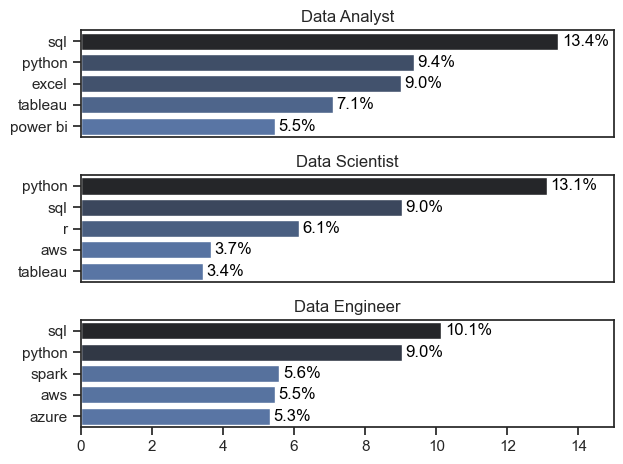

In [49]:
job_titles=['Data Analyst', 'Data Scientist', 'Data Engineer']

fig,ax=plt.subplots(len(job_titles),1)
sns.set_theme(style='ticks')

for i,job in enumerate(job_titles):
    df_plot=df_skills_perc[df_skills_perc['job_title_short']==job].head()
    #df_plot.plot(kind='barh',x='job_skills',y='percentage',ax=ax[i],legend=False,title=job)
    sns.barplot(data=df_plot,x='percentage',y='job_skills',palette='dark:b_r',ax=ax[i],hue='count')
    ax[i].set_ylabel('')
    ax[i].set_xlabel('')
    ax[i].set_title(job)
    ax[i].legend().remove()
    ax[i].set_xlim(0,15)

    for n,v in enumerate(df_plot['percentage']):
        ax[i].text(v+0.1,n,f'{v:.1f}%',color='black',va='center')
    
    if i!=len(job_titles)-1:
        ax[i].set_xticks([])
    

fig.tight_layout()
plt.show()